In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from PIL import Image
from numpy import gradient

# plotly visualize
import plotly.offline as pyo
from glob import glob

pyo.init_notebook_mode(connected=True)

In [ ]:
DATA_ROOT = "../input/00_original/"
# sample_id = "1004283650"
# sample_id = "3320274"
# sample_id = "8862040"
idx = 100
sample_id = (
    glob("../input/00_original/train_images/*.tif")[idx]
    .split("/")[-1]
    .replace(".tif", "")
)

sample_id = "3088997407"


def read_tiff_as_array(tiff_path):
    """Reads a multipage TIFF as a numpy array (D, H, W)"""
    img = Image.open(tiff_path)
    slices = []

    for i in range(img.n_frames):
        img.seek(i)
        frame = np.array(img)
        slices.append(frame)

    return np.stack(slices, axis=0)


volume = read_tiff_as_array(os.path.join(DATA_ROOT, "train_images", f"{sample_id}.tif"))
label = read_tiff_as_array(os.path.join(DATA_ROOT, "train_labels", f"{sample_id}.tif"))

sub = 6
vol_simple = volume[::sub, ::sub, ::sub].astype(np.float32)
label_simple = label[::sub, ::sub, ::sub]

vol_norm = (vol_simple - vol_simple.min()) / (vol_simple.max() - vol_simple.min())
# threshold = np.percentile(vol_norm, 95)
threshold = np.percentile(vol_norm, 50)

Z, Y, X = vol_norm.shape
z_grid, y_grid, x_grid = np.mgrid[0:Z, 0:Y, 0:X]

fig = go.Figure(
    data=go.Isosurface(
        x=x_grid.flatten(),
        y=y_grid.flatten(),
        z=z_grid.flatten(),
        value=vol_norm.flatten(),
        isomin=threshold,
        isomax=vol_norm.max(),
        surface_count=1,
        colorscale="rainbow",
        opacity=0.55,
        caps=dict(x_show=False, y_show=False, z_show=False),
    )
)

fig.update_layout(
    title=f"Lightweight 3D Scan {sub}x: 1004283650",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=750,
    height=700,
    template="plotly_dark",
)

fig.show()

In [ ]:
vol_simple.max(), vol_simple.min(), threshold

(np.float32(255.0), np.float32(0.0), np.float32(0.49803922))

In [ ]:
z, y, x = np.where(label_simple == 1)

fig = go.Figure(
    data=go.Scatter3d(
        x=x, y=y, z=z, mode="markers", marker=dict(size=2.5, color="red", opacity=0.85)
    )
)

fig.update_layout(
    title=f"Simplified Papyrus Surface: 1004283650",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=750,
    height=700,
    template="plotly_dark",
)

fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Isosurface(
        x=x_grid.flatten(),
        y=y_grid.flatten(),
        z=z_grid.flatten(),
        value=vol_norm.flatten(),
        isomin=threshold,
        isomax=vol_norm.max(),
        colorscale="hsv",
        opacity=0.3,
    )
)

fig.add_trace(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="markers",
        marker=dict(size=2, color=z, colorscale="Plasma", opacity=0.9),
        name="Papyrus Layer",
    )
)

fig.update_layout(
    title=f"Scan + Surface {sub}x",
    scene=dict(aspectmode="data"),
    width=800,
    height=700,
    template="plotly_dark",
)

fig.show()

In [ ]:
centroids = []
for z in range(label.shape[0]):
    mask = label[z] == 1
    if np.any(mask):
        y_coords, x_coords = np.where(mask)
        centroids.append([z, y_coords.mean(), x_coords.mean()])

centroids = np.array(centroids)

fig = go.Figure(
    data=go.Scatter3d(
        x=centroids[:, 2],
        y=centroids[:, 1],
        z=centroids[:, 0],
        mode="lines+markers",
        line=dict(color="gold", width=6),
        marker=dict(size=4, color="#FFD700", symbol="circle"),
    )
)

fig.update_layout(
    title="3D Trajectory of Papyrus Layer (Centerline)",
    scene=dict(
        xaxis_title="X (width)",
        yaxis_title="Y (height)",
        zaxis_title="Z (depth)",
        aspectmode="data",
    ),
    width=800,
    height=700,
    template="plotly_dark",
)

fig.show()

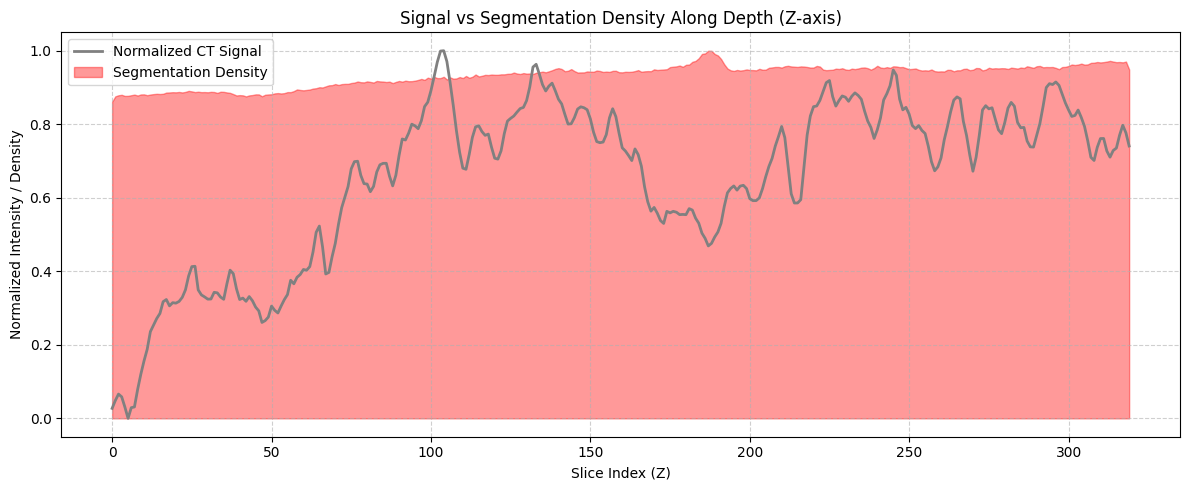

In [ ]:
signal_profile = np.mean(volume, axis=(1, 2))  # signal: average intensity per layer
mask_profile = np.mean(
    (label == 1).astype(float), axis=(1, 2)
)  # mask: the percentage of segmentation pixels per layer

# normalize for comparison
signal_norm = (signal_profile - signal_profile.min()) / (
    signal_profile.max() - signal_profile.min()
)
mask_norm = mask_profile / mask_profile.max()

plt.figure(figsize=(12, 5))
plt.plot(signal_norm, label="Normalized CT Signal", color="gray", linewidth=2)
plt.fill_between(
    range(len(mask_norm)),
    mask_norm,
    color="red",
    alpha=0.4,
    label="Segmentation Density",
)

plt.title("Signal vs Segmentation Density Along Depth (Z-axis)")
plt.xlabel("Slice Index (Z)")
plt.ylabel("Normalized Intensity / Density")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
z_mid = volume.shape[0] // 2
img_slice = volume[z_mid].astype(float)
mask_slice = label[z_mid] == 1

grad_y, grad_x = gradient(img_slice)
edge_strength = np.hypot(grad_x, grad_y)

img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())
edge_norm = (edge_strength - edge_strength.min()) / (
    edge_strength.max() - edge_strength.min()
)

fig = go.Figure()

fig.add_trace(
    go.Heatmap(z=edge_norm, colorscale="Blues", showscale=False, name="Structure")
)

y_mask, x_mask = np.where(mask_slice)
fig.add_trace(
    go.Scatter(
        x=x_mask,
        y=y_mask,
        mode="markers",
        marker=dict(color="red", size=1.2, opacity=0.7),
        name="Papyrus",
    )
)

fig.update_layout(
    title=f"Structural Edges + Papyrus Mask (Z={z_mid})",
    xaxis=dict(scaleanchor="y", scaleratio=1),
    yaxis=dict(autorange="reversed"),
    width=700,
    height=700,
    showlegend=True,
    template="plotly_dark",
)

fig.show()

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from PIL import Image

test_csv_path = "../input/00_original/test.csv"
test_images_dir = "../input/00_original/test_images"

test_df = pd.read_csv(test_csv_path)
test_ids = test_df["id"].tolist()


def read_tiff_as_array(tiff_path):
    """Reads a multipage TIFF as a numpy array (D, H, W)"""
    img = Image.open(tiff_path)
    slices = []

    for i in range(img.n_frames):
        img.seek(i)
        frame = np.array(img)
        slices.append(frame)

    return np.stack(slices, axis=0)


def write_array_as_tiff(arr, out_path):
    """Saves a 3D numpy array as a multi-page TIFF"""
    arr = arr.astype(np.uint8)
    images = [Image.fromarray(arr[i], mode="L") for i in range(arr.shape[0])]
    images[0].save(
        out_path,
        save_all=True,
        append_images=images[1:],
        compression=None,
    )


def create_mask(volume):
    depth, height, width = volume.shape

    mask = np.zeros((depth, height, width), dtype=np.uint8)

    depth_range = max(1, depth // 4)
    d1, d2 = depth // 2 - depth_range, depth // 2 + depth_range

    size_h = max(1, height)
    size_w = max(1, width)

    h1, h2 = height // 2 - size_h, height // 2 + size_h
    w1, w2 = width // 2 - size_w, width // 2 + size_w

    d1, d2 = max(0, d1), min(depth, d2)
    h1, h2 = max(0, h1), min(height, h2)
    w1, w2 = max(0, w1), min(width, w2)

    mask[d1:d2, h1:h2, w1:w2] = 1

    return mask


for test_id in test_ids:
    image_path = os.path.join(test_images_dir, f"{test_id}.tif")

    volume = read_tiff_as_array(image_path)

    mask = create_mask(volume)

    write_array_as_tiff(mask, f"{test_id}.tif")

with zipfile.ZipFile("submission.zip", "w") as zipf:
    for test_id in test_ids:
        zipf.write(f"{test_id}.tif")

In [ ]:
volume.shape

(320, 320, 320)

In [ ]:
mask.shape

(320, 320, 320)

In [ ]:
sub = 6
vol_simple = volume[::sub, ::sub, ::sub].astype(np.float32)
label_simple = mask[::sub, ::sub, ::sub]

vol_norm = (vol_simple - vol_simple.min()) / (vol_simple.max() - vol_simple.min())
threshold = np.percentile(vol_norm, 95)

Z, Y, X = vol_norm.shape
z_grid, y_grid, x_grid = np.mgrid[0:Z, 0:Y, 0:X]

fig = go.Figure(
    data=go.Isosurface(
        x=x_grid.flatten(),
        y=y_grid.flatten(),
        z=z_grid.flatten(),
        value=vol_norm.flatten(),
        isomin=threshold,
        isomax=vol_norm.max(),
        surface_count=1,
        colorscale="rainbow",
        opacity=0.55,
        caps=dict(x_show=False, y_show=False, z_show=False),
    )
)

fig.update_layout(
    title=f"Lightweight 3D Scan {sub}x: 1004283650",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=750,
    height=700,
    template="plotly_dark",
)

fig.show()

In [ ]:
z, y, x = np.where(label_simple == 1)

fig = go.Figure(
    data=go.Scatter3d(
        x=x, y=y, z=z, mode="markers", marker=dict(size=2.5, color="red", opacity=0.85)
    )
)

fig.update_layout(
    title=f"Simplified Papyrus Surface: 1004283650",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=750,
    height=700,
    template="plotly_dark",
)

fig.show()